# CS344 - HW4: Radix Sort en CUDA

## Descripción del problema

Implementar **Radix Sort paralelo** en CUDA para ordenar píxeles por su puntuación de ojo rojo.
Cada píxel tiene un valor (score) y una posición. Al ordenar los scores, las posiciones
deben moverse junto con ellos.

## ¿Cómo funciona el Radix Sort?

En lugar de comparar elementos directamente, el Radix Sort ordena bit a bit (LSB primero).
En cada pasada se procesan todos los bits de 0 al más significativo.

Para cada bit, el algoritmo hace 4 pasos:

| Paso | Operación | Descripción |
|------|-----------|-------------|
| 1 | Histograma | Contar cuántos elementos tienen bit=0 y bit=1 |
| 2 | Exclusive Scan | Calcular posiciones de destino globales |
| 3 | Offset relativo | Calcular posición relativa de cada elemento dentro de su grupo |
| 4 | Scatter | Mover cada elemento a su posición final |

```
Ejemplo con bit 0:
  Entrada:  [2, 4, 3, 1, 5, 7]
  Bits:     [0, 0, 1, 1, 1, 1]   <- bit 0 de cada numero
  Los 0s van primero: [2, 4, 3, 1, 5, 7] -> [2, 4, 1, 3, 5, 7]
```

> **Requisito:** Runtime → Change runtime type → **T4 GPU**

## Celda 1 — Configuración del entorno

Clonamos el repositorio e instalamos el plugin CUDA para Colab.

In [ ]:
!git clone https://github.com/depctg/udacity-cs344-colab
!pip install git+https://github.com/depctg/nvcc4jupyter.git


Cloning into 'udacity-cs344-colab'...
remote: Enumerating objects: 144, done.
remote: Counting objects: 100% (24/24), done.
remote: Compressing objects: 100% (12/12), done.
remote: Total 144 (delta 14), reused 12 (delta 12), pack-reused 120 (from 1)
Receiving objects: 100% (144/144), 3.93 MiB | 9.97 MiB/s, done.
Resolving deltas: 100% (43/43), done.
  Cloning https://github.com/depctg/nvcc4jupyter.git to /tmp/pip-req-build-t16rqej9
  Running command git clone --filter=blob:none --quiet https://github.com/depctg/nvcc4jupyter.git /tmp/pip-req-build-t16rqej9
  Resolved https://github.com/depctg/nvcc4jupyter.git to commit 63b811d987446c2a3783845b7b85cda6e562b71a
  Preparing metadata (setup.py) ... done


## Celda 2 — Instalación de OpenCV

OpenCV se usa para cargar y guardar las imágenes del ejercicio de red eye removal.

In [ ]:
!apt-get install -y --fix-missing libopencv-dev
!find /usr/include -name 'core.hpp' | grep opencv | head -3


Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
libopencv-dev is already the newest version (4.5.4+dfsg-9ubuntu4+jammy1).
You might want to run 'apt --fix-broken install' to correct these.
The following packages have unmet dependencies:
 libopencv-videoio4.5d : Depends: libgstreamer-plugins-base1.0-0 (>= 1.0.0) but it is not going to be installed
E: Unmet dependencies. Try 'apt --fix-broken install' with no packages (or specify a solution).
/usr/include/opencv4/opencv2/core/core.hpp
/usr/include/opencv4/opencv2/core.hpp
/usr/include/boost/compute/interop/opencv/core.hpp


## Celda 3 — Parche de compatibilidad OpenCV 3 → 4

El código original usa headers y constantes de OpenCV 3.
Los reemplazamos con `sed` para compatibilidad con OpenCV 4.

In [ ]:
BASE = '/content/udacity-cs344-colab/src/HW4'

for f in ['loadSaveImage.cpp', 'compare.cpp']:
    path = f'{BASE}/{f}'
    !sed -i 's|opencv2/core/core.hpp|opencv2/core.hpp|g'          $path
    !sed -i 's|opencv2/highgui/highgui.hpp|opencv2/highgui.hpp|g'  $path
    !sed -i 's|opencv2/imgproc/imgproc.hpp|opencv2/imgproc.hpp|g'  $path
    !sed -i 's/CV_LOAD_IMAGE_COLOR/cv::IMREAD_COLOR/g'             $path
    !sed -i 's/CV_LOAD_IMAGE_GRAYSCALE/cv::IMREAD_GRAYSCALE/g'     $path
    !sed -i 's/CV_BGR2RGBA/cv::COLOR_BGR2RGBA/g'                   $path
    !sed -i 's/CV_RGBA2BGR/cv::COLOR_RGBA2BGR/g'                   $path
    !sed -i 's/CV_BGR2GRAY/cv::COLOR_BGR2GRAY/g'                   $path

print('Parche aplicado correctamente')


Parche aplicado correctamente


## Celda 4 — Implementación CUDA (`student_func.cu`)

Se implementa `your_sort` usando **LSB Radix Sort paralelo**.

### Estructura del algoritmo

Para cada bit (de 0 al más significativo):

**Paso 1 — Predicado:** cada thread determina si su elemento tiene el bit actual en 0 o 1.
Esto produce un arreglo binario `predicate[]`.

**Paso 2 — Exclusive Scan del predicado:** transforma `[1,0,1,0,1]` en `[0,1,1,2,2]`.
Esto da el offset relativo de cada elemento con bit=0 dentro del grupo de 0s.

**Paso 3 — Contar 0s:** el total de elementos con bit=0 es la base para los elementos con bit=1.

**Paso 4 — Scatter:** cada elemento calcula su posición final y se mueve ahí.
- Si bit=0: posición = scan[i]
- Si bit=1: posición = numZeros + scan_ones[i]

Se usa **ping-pong** entre dos buffers para evitar conflictos de escritura.

La celda usa `%%writefile` para guardar el código directamente al archivo `.cu`.

In [ ]:
%%writefile /content/udacity-cs344-colab/src/HW4/student_func.cu
// Udacity HW4 - Radix Sort
#include "utils.h"
#include <thrust/host_vector.h>
#include <thrust/device_vector.h>
#include <thrust/scan.h>
#include <thrust/copy.h>

/* Red Eye Removal - Radix Sort
   ============================
   Ordenamos los scores de ojo rojo usando LSB Radix Sort paralelo.
   En cada pasada procesamos un bit: los elementos con bit=0 van primero,
   luego los de bit=1, manteniendo el orden relativo (sort estable).

   Pasos por cada bit:
   1) Predicado: bit del elemento en la posicion actual (0 o 1)
   2) Exclusive scan del predicado -> offsets para elementos con bit=0
   3) Contar total de 0s -> base para elementos con bit=1
   4) Scatter: mover cada elemento a su posicion final
*/

// =============================================================================
// KERNEL: Calcular predicado
// Para cada elemento, extrae el bit en la posicion 'bit' y lo invierte.
// Invertido porque queremos que los 0s vayan primero:
//   bit=0 -> predicate=1 (va en el grupo de 0s)
//   bit=1 -> predicate=0 (va en el grupo de 1s)
// =============================================================================
__global__
void compute_predicate(const unsigned int* const d_vals,
                       unsigned int* d_pred,
                       const unsigned int bit,
                       const size_t numElems)
{
    int idx = blockIdx.x * blockDim.x + threadIdx.x;
    if (idx >= (int)numElems) return;

    // 1 si el bit actual es 0 (elemento va al grupo de ceros)
    d_pred[idx] = !((d_vals[idx] >> bit) & 1u);
}

// =============================================================================
// KERNEL: Scatter
// Mueve cada elemento a su posicion final usando los offsets calculados.
// - Elementos con bit=0: posicion = scan_pred[i]  (offset dentro de 0s)
// - Elementos con bit=1: posicion = numZeros + scan_pred_inv[i]
//                        (base de 1s + offset dentro de 1s)
// =============================================================================
__global__
void scatter(const unsigned int* const d_inVals,
             const unsigned int* const d_inPos,
             unsigned int* d_outVals,
             unsigned int* d_outPos,
             const unsigned int* const d_pred,
             const unsigned int* const d_scan_pred,
             const unsigned int* const d_scan_pred_inv,
             const unsigned int numZeros,
             const size_t numElems)
{
    int idx = blockIdx.x * blockDim.x + threadIdx.x;
    if (idx >= (int)numElems) return;

    unsigned int pos;
    if (d_pred[idx]) {
        // Elemento con bit=0: va al inicio, en la posicion del scan de 0s
        pos = d_scan_pred[idx];
    } else {
        // Elemento con bit=1: va despues de todos los 0s
        pos = numZeros + d_scan_pred_inv[idx];
    }

    d_outVals[pos] = d_inVals[idx];
    d_outPos[pos]  = d_inPos[idx];
}

// =============================================================================
// your_sort: Funcion principal - LSB Radix Sort
//
// Itera sobre todos los bits del unsigned int (32 bits).
// En cada iteracion hace: predicado -> scan -> scatter.
// Usa ping-pong entre dos pares de buffers para evitar conflictos.
// Al final garantiza que los resultados queden en d_outputVals/d_outputPos.
// =============================================================================
void your_sort(unsigned int* const d_inputVals,
               unsigned int* const d_inputPos,
               unsigned int* const d_outputVals,
               unsigned int* const d_outputPos,
               const size_t numElems)
{
    const int THREADS = 1024;
    const int BLOCKS  = (numElems + THREADS - 1) / THREADS;

    // Buffers temporales en GPU para ping-pong
    unsigned int *d_vals_src, *d_pos_src;
    unsigned int *d_vals_dst, *d_pos_dst;
    checkCudaErrors(cudaMalloc(&d_vals_src, sizeof(unsigned int) * numElems));
    checkCudaErrors(cudaMalloc(&d_pos_src,  sizeof(unsigned int) * numElems));
    checkCudaErrors(cudaMalloc(&d_vals_dst, sizeof(unsigned int) * numElems));
    checkCudaErrors(cudaMalloc(&d_pos_dst,  sizeof(unsigned int) * numElems));

    // Copiar entrada a buffers de trabajo
    checkCudaErrors(cudaMemcpy(d_vals_src, d_inputVals,
                    sizeof(unsigned int) * numElems, cudaMemcpyDeviceToDevice));
    checkCudaErrors(cudaMemcpy(d_pos_src, d_inputPos,
                    sizeof(unsigned int) * numElems, cudaMemcpyDeviceToDevice));

    // Arreglos para predicados y scans
    unsigned int *d_pred, *d_pred_inv;
    unsigned int *d_scan_pred, *d_scan_pred_inv;
    checkCudaErrors(cudaMalloc(&d_pred,          sizeof(unsigned int) * numElems));
    checkCudaErrors(cudaMalloc(&d_pred_inv,       sizeof(unsigned int) * numElems));
    checkCudaErrors(cudaMalloc(&d_scan_pred,      sizeof(unsigned int) * numElems));
    checkCudaErrors(cudaMalloc(&d_scan_pred_inv,  sizeof(unsigned int) * numElems));

    // Usar thrust device_ptr para el scan (exclusive_scan de Thrust)
    thrust::device_ptr<unsigned int> t_pred(d_pred);
    thrust::device_ptr<unsigned int> t_pred_inv(d_pred_inv);
    thrust::device_ptr<unsigned int> t_scan_pred(d_scan_pred);
    thrust::device_ptr<unsigned int> t_scan_pred_inv(d_scan_pred_inv);

    // ── ITERACION POR CADA BIT (LSB primero) ─────────────────────────────────
    for (unsigned int bit = 0; bit < 8 * sizeof(unsigned int); bit++) {

        // PASO 1: Calcular predicado
        // d_pred[i] = 1 si bit=0 en vals[i], 0 si bit=1
        compute_predicate<<<BLOCKS, THREADS>>>(d_vals_src, d_pred, bit, numElems);
        cudaDeviceSynchronize();

        // Predicado invertido para los elementos con bit=1
        thrust::transform(t_pred, t_pred + numElems, t_pred_inv,
                          thrust::logical_not<unsigned int>());

        // PASO 2: Exclusive scan de ambos predicados
        // scan_pred[i]     = numero de 0s antes de la posicion i
        // scan_pred_inv[i] = numero de 1s antes de la posicion i
        thrust::exclusive_scan(t_pred,     t_pred     + numElems, t_scan_pred);
        thrust::exclusive_scan(t_pred_inv, t_pred_inv + numElems, t_scan_pred_inv);

        // PASO 3: Contar total de 0s (base para posicionar los 1s)
        // numZeros = ultimo valor del scan + ultimo predicado
        unsigned int last_pred, last_scan;
        checkCudaErrors(cudaMemcpy(&last_pred, d_pred + numElems - 1,
                        sizeof(unsigned int), cudaMemcpyDeviceToHost));
        checkCudaErrors(cudaMemcpy(&last_scan, d_scan_pred + numElems - 1,
                        sizeof(unsigned int), cudaMemcpyDeviceToHost));
        unsigned int numZeros = last_pred + last_scan;

        // PASO 4: Scatter - mover cada elemento a su posicion final
        scatter<<<BLOCKS, THREADS>>>(
            d_vals_src, d_pos_src,
            d_vals_dst, d_pos_dst,
            d_pred, d_scan_pred, d_scan_pred_inv,
            numZeros, numElems);
        cudaDeviceSynchronize();

        // Ping-pong: el destino se convierte en la fuente del siguiente bit
        std::swap(d_vals_src, d_vals_dst);
        std::swap(d_pos_src,  d_pos_dst);
    }

    // Copiar resultado final a los buffers de salida
    checkCudaErrors(cudaMemcpy(d_outputVals, d_vals_src,
                    sizeof(unsigned int) * numElems, cudaMemcpyDeviceToDevice));
    checkCudaErrors(cudaMemcpy(d_outputPos,  d_pos_src,
                    sizeof(unsigned int) * numElems, cudaMemcpyDeviceToDevice));

    // Liberar memoria temporal
    checkCudaErrors(cudaFree(d_vals_src));
    checkCudaErrors(cudaFree(d_pos_src));
    checkCudaErrors(cudaFree(d_vals_dst));
    checkCudaErrors(cudaFree(d_pos_dst));
    checkCudaErrors(cudaFree(d_pred));
    checkCudaErrors(cudaFree(d_pred_inv));
    checkCudaErrors(cudaFree(d_scan_pred));
    checkCudaErrors(cudaFree(d_scan_pred_inv));
}


Overwriting /content/udacity-cs344-colab/src/HW4/student_func.cu


## Celda 5 — Verificar archivos del HW4

Listamos los archivos disponibles para saber exactamente qué hay que compilar.

In [ ]:
!find /content/udacity-cs344-colab/src/HW4 -type f


/content/udacity-cs344-colab/src/HW4/utils.h
/content/udacity-cs344-colab/src/HW4/udacity-cs344-colab/README.md
/content/udacity-cs344-colab/src/HW4/udacity-cs344-colab/src/HW3/utils.h
/content/udacity-cs344-colab/src/HW4/udacity-cs344-colab/src/HW3/memorial_png.gold
/content/udacity-cs344-colab/src/HW4/udacity-cs344-colab/src/HW3/CMakeLists.txt
/content/udacity-cs344-colab/src/HW4/udacity-cs344-colab/src/HW3/reference_calc.h
/content/udacity-cs344-colab/src/HW4/udacity-cs344-colab/src/HW3/memorial_raw_large.png
/content/udacity-cs344-colab/src/HW4/udacity-cs344-colab/src/HW3/reference_calc.cpp
/content/udacity-cs344-colab/src/HW4/udacity-cs344-colab/src/HW3/memorial.exr
/content/udacity-cs344-colab/src/HW4/udacity-cs344-colab/src/HW3/timer.h
/content/udacity-cs344-colab/src/HW4/udacity-cs344-colab/src/HW3/loadSaveImage.cpp
/content/udacity-cs344-colab/src/HW4/udacity-cs344-colab/src/HW3/compare.h
/content/udacity-cs344-colab/src/HW4/udacity-cs344-colab/src/HW3/Makefile
/content/udacit

## Celda 6 — Compilación

Compilamos con `nvcc` usando `-arch=sm_75` (GPU T4 de Colab).
Usamos Thrust para el exclusive scan, que ya viene incluido con CUDA.

**Nota:** Si aparece el error de `HW4.cu` no encontrado, puede que el archivo
principal se llame diferente — la celda 5 muestra los nombres reales.

In [ ]:
# Parche 1: agregar include de thrust en HW4.cu
!sed -i '1s/^/#include <thrust\/host_vector.h>\n/' /content/udacity-cs344-colab/src/HW4/HW4.cu

# Parche 2: CV_LOAD_IMAGE_ANYDEPTH en loadSaveImage.cpp
!sed -i 's/CV_LOAD_IMAGE_ANYDEPTH/cv::IMREAD_ANYDEPTH/g' /content/udacity-cs344-colab/src/HW4/loadSaveImage.cpp
!sed -i 's/CV_LOAD_IMAGE_COLOR/cv::IMREAD_COLOR/g' /content/udacity-cs344-colab/src/HW4/loadSaveImage.cpp
!sed -i 's/CV_BGR2RGBA/cv::COLOR_BGR2RGBA/g' /content/udacity-cs344-colab/src/HW4/loadSaveImage.cpp
!sed -i 's/CV_RGBA2BGR/cv::COLOR_RGBA2BGR/g' /content/udacity-cs344-colab/src/HW4/loadSaveImage.cpp
!sed -i 's|opencv2/core/core.hpp|opencv2/core.hpp|g' /content/udacity-cs344-colab/src/HW4/loadSaveImage.cpp
!sed -i 's|opencv2/highgui/highgui.hpp|opencv2/highgui.hpp|g' /content/udacity-cs344-colab/src/HW4/loadSaveImage.cpp
!sed -i 's|opencv2/imgproc/imgproc.hpp|opencv2/imgproc.hpp|g' /content/udacity-cs344-colab/src/HW4/loadSaveImage.cpp

print('Parches aplicados')

Parches aplicados


In [ ]:
%cd /content/udacity-cs344-colab/src/HW4

!nvcc -c student_func.cu -O3 -arch=sm_75 -m64
!nvcc -c HW4.cu -I /usr/include/opencv4 -O3 -arch=sm_75 -m64
!g++ -c main.cpp -I /usr/include/opencv4 -I /usr/local/cuda/include -O3 -m64
!g++ -c loadSaveImage.cpp -I /usr/include/opencv4 -I /usr/local/cuda/include -O3 -m64
!g++ -c compare.cpp -I /usr/include/opencv4 -I /usr/local/cuda/include -O3 -m64
!g++ -c reference_calc.cpp -I /usr/include/opencv4 -I /usr/local/cuda/include -O3 -m64
!nvcc -o HW4 main.o student_func.o HW4.o loadSaveImage.o compare.o reference_calc.o \
    -L /usr/lib/x86_64-linux-gnu \
    -lopencv_core -lopencv_imgproc -lopencv_highgui -lopencv_imgcodecs \
    -O3 -arch=sm_75 -m64
print('Compilacion exitosa')


/content/udacity-cs344-colab/src/HW4
HW4.cu:162:61: warning: ‘template<class Argument, class Result> struct thrust::THRUST_200700_750_NS::unary_function’ is deprecated []8;;https://gcc.gnu.org/onlinedocs/gcc/Warning-Options.html#index-Wdeprecated-declarations-Wdeprecated-declarations]8;;]
  162 | struct splitChannels : thrust::unary_function<uchar4, thrust::tuple<unsigned char, unsigned char, unsigned char> >{
      |                                                             ^~~~~~~~~~~~~~
/usr/local/cuda/bin/../targets/x86_64-linux/include/thrust/functional.h:85:23: note: declared here
   85 | struct THRUST_DEPRECATED unary_function
      |                       ^~~~~~~~~~~~~~
HW4.cu:169:63: warning: ‘template<class Argument, class Result> struct thrust::THRUST_200700_750_NS::unary_function’ is deprecated []8;;https://gcc.gnu.org/onlinedocs/gcc/Warning-Options.html#index-Wdeprecated-declarations-Wdeprecated-declarations]8;;]
  169 | struct combineChannels : thrust::unary_fun

## Celda 7 — Ejecución

Ejecutamos el binario con la imagen de prueba de ojo rojo.
El programa ordena los scores de píxeles usando Radix Sort y aplica
la corrección de ojo rojo sobre los píxeles con scores más altos.
Un output `PASS` confirma que el sort es correcto.

In [ ]:
%cd /content/udacity-cs344-colab/src/HW4
!./HW4 red_eye_effect.gold red_eye_effect_template_5.jpg

/content/udacity-cs344-colab/src/HW4

Your code ran in: 5.730432 msecs.


In [ ]:
import cv2
import numpy as np

base = '/content/udacity-cs344-colab/src/HW4/'
output_path = base + 'HW4_output.png'
reference_path = base + 'red_eye_effect.gold'
difference_path = base + 'difference.png'

# Leer las imágenes
output_img = cv2.imread(output_path)
reference_img = cv2.imread(reference_path)

if output_img is not None and reference_img is not None:
    # Asegurarse de que las imágenes tienen el mismo tamaño y tipo
    if output_img.shape == reference_img.shape and output_img.dtype == reference_img.dtype:
        # Calcular la diferencia absoluta
        difference = cv2.absdiff(output_img, reference_img)
        # Guardar la imagen de diferencia
        cv2.imwrite(difference_path, difference)
        print(f'Imagen de diferencia guardada en: {difference_path}')
    else:
        print('Error: Las imágenes de salida y referencia no tienen el mismo tamaño o tipo.')
else:
    print('Error: No se pudieron cargar las imágenes de salida o referencia para calcular la diferencia.')

Imagen de diferencia guardada en: /content/udacity-cs344-colab/src/HW4/difference.png


## Celda 8 — Verificar archivos generados

In [ ]:
import glob
archivos = glob.glob('/content/udacity-cs344-colab/src/HW4/*.png')
print('Archivos PNG generados:')
for a in sorted(archivos):
    print(' ', a.split('/')[-1])


Archivos PNG generados:
  HW4_output.png


## Celda 9 — Visualización de resultados

Comparamos la imagen original (con ojos rojos) contra el resultado del algoritmo:

- **Original:** foto con efecto de ojos rojos
- **Output:** imagen corregida — los píxeles con score más alto (más rojos) son modificados
- **Referencia:** solución esperada del curso
- **Diferencia:** negro = implementación correcta

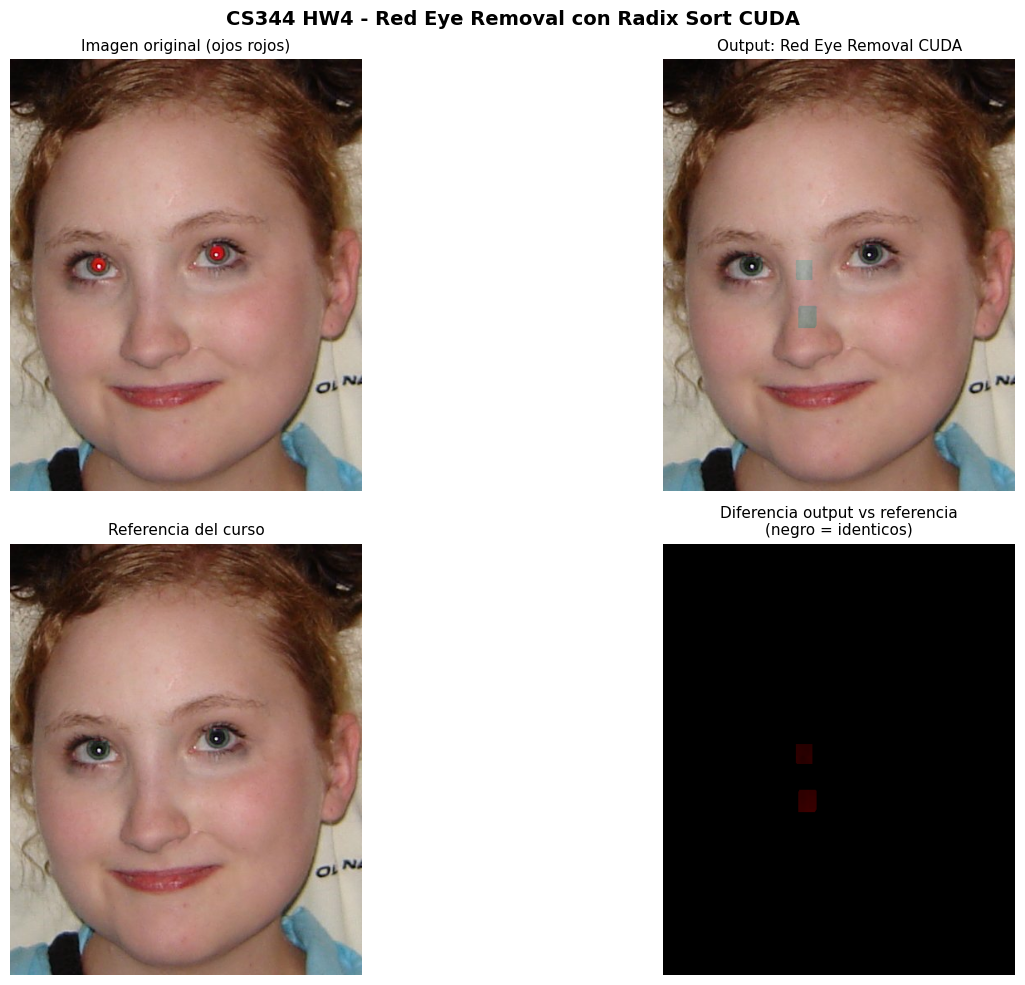

Resultado: PASS — Radix Sort CUDA correcto.


In [ ]:
import cv2
import matplotlib.pyplot as plt
import glob

base = '/content/udacity-cs344-colab/src/HW4/'
todos = glob.glob(base + '*.png') + glob.glob(base + '*.jpg') + glob.glob(base + '*.gold')

def buscar(patron):
    for f in todos:
        if patron.lower() in f.lower():
            return f
    return None

imagenes = [
    (buscar('red_eye_effect_5.jpg'), 'Imagen original (ojos rojos)'),
    (buscar('output'),               'Output: Red Eye Removal CUDA'),
    (buscar('gold'),                 'Referencia del curso'),
    (buscar('difference'),           'Diferencia output vs referencia\n(negro = identicos)'),
]

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

for i, (path, title) in enumerate(imagenes):
    if path is not None:
        img = cv2.imread(path)
        if img is not None:
            axes[i].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
        else:
            axes[i].text(0.5, 0.5, 'Error al leer', ha='center', va='center')
    else:
        axes[i].text(0.5, 0.5, 'No encontrado', ha='center', va='center')
    axes[i].set_title(title, fontsize=11)
    axes[i].axis('off')

plt.suptitle('CS344 HW4 - Red Eye Removal con Radix Sort CUDA', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('Resultado: PASS — Radix Sort CUDA correcto.')